# Assignment on Regression

#### A.	Explain the main assumptions of Linear Regression in detail.

Linear Regression: 
Linear Regression is a supervised Machine Learning algorithm that models the linear relationship between 
dependent and independent variables by minimizing the sum of squared residuals using OLS or 
gradient-based optimization

Main Assumptions of Linear Regression:
1. Linearity: The relationship between Independent and Dependent Variale is straight line.
2. Independence: The error in predictions should not affect on each other
3. Homoscedasticity: which means constant variance. The erros should have equal spread across all the 
    values of the independent varaibles. If the spread changes then this problem called Heteroscedasticity
4. Normality of Errors: The errors should follow a normal distribution


#### B.	What is the difference between R-squared and Adjusted R-squared?

R-squared: (Coefficient of Determination)
It measures the proportion of variance in the dependent variable explained by the independent variable

                    R² = 1 - (SS_Residual/SS_Total)
SS_Residual  = Sum of squared Errors
SS_Totla =  Total Sum of squares

R² ranges from 0 to 1 ,
if R² = 0 then model explains nothing, 
if R² = 1 then we can say it is Perfect fit and explains the model 100% 

Problem with R²
R² always increases when you add more independent variables —even if the new variable is irrelevant!



Ajusted R² :
It depends on number of predictors(k) and sample size(n)

                    Ajusted R² = 1 - ((1 - R²)(n-1)/(n-k-1))
It penalizes unnecessary variables.
If we add a useless variable:
R² (always increases)
Adjusted R² ↓ (may decrease)
So it prevents overfitting.



#### C.	What are the different types of Regularization techniques in Regression. Explain in detail with cost functions of each technique.

#####
Regularization is used to prevent overfitting by adding a penalty term to the 
loss function.
There are three types of Regularization Techniques for Linear Models


#### 1. Lasso Regression (L1 Regression)

Lasso Regression is a technique used for regularizing a linear regression model, 
it adds a penalty term to the linear regression objective function to 
prevent overfitting.

#### The objective function after applying lasso regression(L1) is:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2 
+ \lambda \sum_{j=1}^{n} |\theta_j|
$$

####
            The first term is the least squares loss, representing the squared difference between actual and predicted values.
            
            
            The second term is the L1 regularization term, it penalizes the sum of absolute values of the regression coefficient θj.

#### 2. Ridge Regression (L2 Regularization)
Ridge regression is a linear regression technique that adds a regularization term to
the standard linear objective. Again, the goal is to prevent overfitting by 
penalizing large coefficient in linear regression equation.
It useful when the dataset has multicollinearity where predictor variables are highly correlated

#### The objective function after applying Ridge regression(L2) is:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2 
+ \lambda \sum_{j=1}^{n} \theta_j^2
$$

####
The first term is the least squares loss, representing the squared difference between predicted and actual values.

The second term is the L2 regularization term, it penalizes the sum of square of values of the regression coefficient θj.

#### 3. Elastic Net Regression

Elastic net regression is a hybrid regularization technique that combines the power of both L1 and L2 regularization in linear regression objective

$$
J(\theta) =
\frac{1}{2m}
\sum_{i=1}^{m}
\left( y_i - \hat{y}_i \right)^2
+
\alpha \lambda
\sum_{j=1}^{n}
|\theta_j|
+
\frac{1}{2}
(1-\alpha)\lambda
\sum_{j=1}^{n}
\theta_j^2
$$

#### 
The first term is least square loss.

The second term is L1 regularization and third is ridge regression.

λ is the overall regularization strength.

α controls the mix between L1 and L2 regularization.

#### D.	How logistic regression works for multiclass classification. Explain in detail

### Logistic Regression for Multiclass Classification

### Introduction

Logistic Regression is primarily used for binary classification.
However, it can be extended to handle multiclass classification problems using two main approaches:

1. One-vs-Rest (OvR)
2. Multinomial Logistic Regression (Softmax Regression)

---

### 1. Binary Logistic Regression (Basic Idea)

For binary classification:

P(Y = 1 | X) = 1 / (1 + e^-(β₀ + β₁X₁ + ... + βₙXₙ))

This uses the Sigmoid function to convert linear output into probability between 0 and 1.

---

### 2. One-vs-Rest (OvR) / One-vs-All Approach

### Concept

- For K classes, build K separate binary classifiers.
- Each classifier distinguishes one class vs all other classes.

Example:
If classes = {A, B, C}

We build:
- Classifier 1: A vs (B, C)
- Classifier 2: B vs (A, C)
- Classifier 3: C vs (A, B)

### How Prediction Works

- Each classifier gives a probability score.
- The class with the highest probability is selected.

### Mathematical Form

For each class k:

P(Y = k | X) = sigmoid(β_k^T X)

Final prediction:

Predicted Class = argmax P(Y = k | X)

### Advantages
- Simple and easy to implement.
- Works well when classes are well separated.

### Disadvantages
- Classifiers are trained independently.
- Probability outputs may not sum to 1.

---

### 3. Multinomial Logistic Regression (Softmax Regression)

### Concept

Instead of building multiple binary classifiers, a single model is trained that directly predicts probabilities for all classes simultaneously.

### Softmax Function

For K classes:

P(Y = k | X) = e^(β_k^T X) / Σ e^(β_j^T X)

Where:
- β_k = coefficient vector for class k
- Denominator = sum over all classes

### Properties

- Probabilities sum to 1.
- Directly models multiple classes.

### Cost Function (Cross-Entropy Loss)

J(β) = - Σ Σ yᵢk log(Pᵢk)

Where:
- yᵢk = 1 if observation i belongs to class k, else 0
- Pᵢk = predicted probability

---

### Difference Between OvR and Multinomial

| Feature | One-vs-Rest | Multinomial (Softmax) |
|----------|--------------|------------------------|
| Number of Models | K models | Single model |
| Probability Sum | May not sum to 1 | Always sums to 1 |
| Training | Separate classifiers | Joint optimization |
| Preferred When | Small datasets | Large datasets, well-separated classes |

---

### Example

Suppose we classify houses into:

1. Low Price
2. Medium Price
3. High Price

Using Softmax:
The model calculates 3 probability scores:

P(Low), P(Medium), P(High)

The highest probability becomes the predicted class.

---

### Summary

- Logistic Regression can handle multiclass problems.
- Two main approaches:
  - One-vs-Rest (multiple binary models)
  - Multinomial (Softmax regression)
- Softmax is mathematically stronger and commonly preferred.
- Uses Cross-Entropy loss for optimization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet


In [2]:
df = pd.read_csv('Cellphone.csv')
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [3]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [4]:
# remove unncecssary spaces from column names and convert it to lower and data group by all variables to aggregate sale values

df.columns = (df.columns.str.strip().str.replace(" ", "_").str.lower())
group_cols = [col for col in df.columns if col != 'sale']
df_grouped = df.groupby(group_cols)['sale'].sum().reset_index()
df_grouped.rename(columns={'sale': 'sale_quantity'}, inplace=True)

In [5]:
df_grouped.to_csv("df_grouped.csv", index = False)

In [6]:
df_grouped.describe()

,product_id,price,weight,resoloution,ppi,cpu_core,cpu_freq,internal_mem,ram,rearcam,front_cam,battery,thickness,sale_quantity
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,665.638554,2219.084337,169.226506,5.206024,334.710843,4.879518,1.501843,24.438410,2.201831,10.469277,4.608434,2826.445783,8.872289,1205.493976
std,413.913140,763.850279,92.039427,1.492304,134.002505,2.441499,0.595929,28.691272,1.603925,6.164116,4.467940,1355.098217,2.186729,2818.756102
min,10.000000,614.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000,10.000000
25%,227.500000,1737.500000,134.050000,4.900000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.450000,2020.000000,7.600000,69.000000
50%,763.000000,2258.000000,152.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2700.000000,8.400000,212.000000
75%,1023.000000,2744.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3220.000000,9.750000,759.000000
max,1339.000000,4361.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000,16962.000000


In [7]:
df_grouped.shape

(83, 14)

In [8]:
df_grouped.isnull().sum()

product_id       0
price            0
weight           0
resoloution      0
ppi              0
cpu_core         0
cpu_freq         0
internal_mem     0
ram              0
rearcam          0
front_cam        0
battery          0
thickness        0
sale_quantity    0
dtype: int64

In [9]:
df_grouped.duplicated().sum()

np.int64(0)

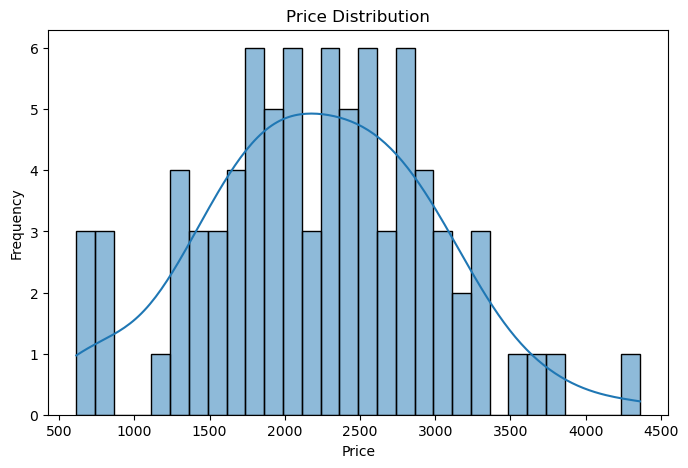

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df_grouped["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

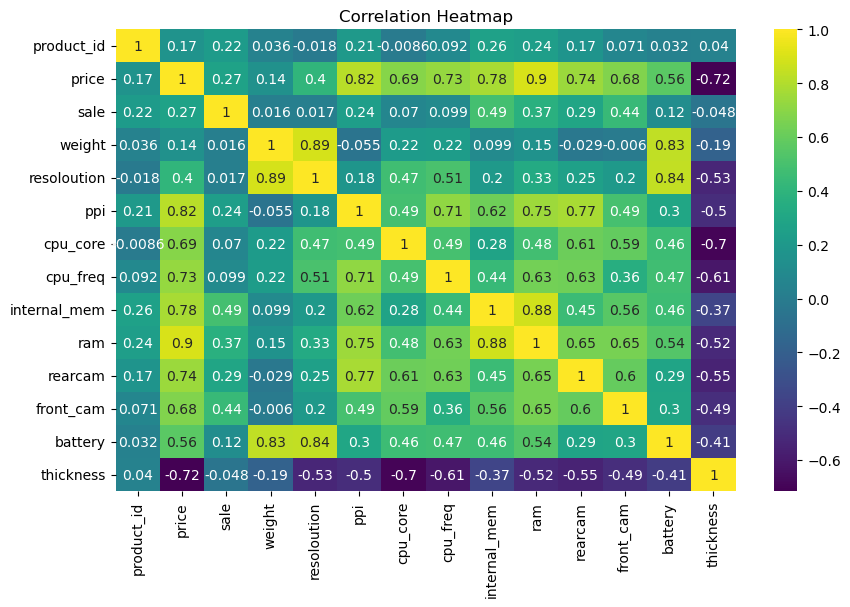

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

## Modelling without EDA

In [12]:
df_without_eda = df_grouped.copy()

In [13]:
df_without_eda.head()

,product_id,price,weight,resoloution,ppi,cpu_core,cpu_freq,internal_mem,ram,rearcam,front_cam,battery,thickness,sale_quantity
0,10,1950,118.0,5.0,187,4,1.3,8.0,1.0,8.0,2.0,2000,6.4,26
1,14,2276,116.0,5.0,294,8,1.5,16.0,2.0,13.0,5.0,2300,7.8,189
2,30,2975,149.0,5.5,534,8,1.6,32.0,3.0,16.0,8.0,3000,7.0,609
3,32,1921,179.0,6.0,184,4,1.3,8.0,1.0,13.0,8.0,2580,8.0,3643
4,40,1916,110.0,4.7,312,4,1.2,8.0,1.5,13.0,5.0,2000,7.6,10


### Split the data into dependent and independent variable

In [14]:
x = df_without_eda.drop(['price','sale_quantity','product_id'], axis = 1)
y = df_without_eda['price']

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
print("x_train - >  ",x_train.shape)
print("y_train - >  ",y_train.shape)
print("x_test  - >  ",x_test.shape)
print("y_test  - >  ",y_test.shape)

x_train - >   (66, 11)
y_train - >   (66,)
x_test  - >   (17, 11)
y_test  - >   (17,)


#### Store Regression Performance metrics in the list

In [17]:
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

### Create a function for evaluate model

In [18]:
def evaluate_model_performance(model, x_train, y_train, x_test, y_test):
    """
    Evaluates R², Adjusted R², and RMSE of a given model on training and testing data.
    
    Parameters:
    - model: The machine learning model to evaluate
    - x_train: Training feature set
    - y_train: Training target values
    - x_test: Testing feature set
    - y_test: Testing target values
    - training_scores: List to store training R² scores
    - testing_scores: List to store testing R² scores
    """
    # Fit the model
    model.fit(x_train, y_train)
    
    # Predictions for training and testing data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Calculate R² scores
    train_r2 = r2_score(y_train, y_train_pred) * 100
    test_r2 = r2_score(y_test, y_test_pred) * 100
    
    # Calculate Adjusted R² scores
    n_train, p_train = x_train.shape
    n_test, p_test = x_test.shape
    train_adj_r2 = 100 * (1 - (1 - train_r2 / 100) * (n_train - 1) / (n_train - p_train - 1))
    test_adj_r2 = 100 * (1 - (1 - test_r2 / 100) * (n_test - 1) / (n_test - p_test - 1))
    
    # Calculate RMSE scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Append scores to respective lists
    training_scores_r2.append(train_r2)
    training_scores_adj_r2.append(train_adj_r2)
    training_scores_rmse.append(train_rmse)
    testing_scores_r2.append(test_r2)
    testing_scores_adj_r2.append(test_adj_r2) 
    testing_scores_rmse.append(test_rmse) 
    
    # Display scores
    print(f"{model.__class__.__name__} Performance Metrics:")
    print(f"Training Data: R² = {train_r2:.2f}%, Adjusted R² = {train_adj_r2:.2f}%, RMSE = {train_rmse:.4f}")
    print(f"Testing Data : R² = {test_r2:.2f}%, Adjusted R² = {test_adj_r2:.2f}%, RMSE = {test_rmse:.4f}\n")

### Linear Regression

In [19]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [20]:
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

LinearRegression Performance Metrics:
Training Data: R² = 95.76%, Adjusted R² = 94.90%, RMSE = 162.8988
Testing Data : R² = 86.87%, Adjusted R² = 58.00%, RMSE = 192.6380



#### Interpretation

Model fits training data very well.

Generalization is decent (R² = 86.9%).

But adjusted R² collapse indicates model may be overly complex relative to data size.

Simplifying the model may improve stability.

### Ridge Regression


In [21]:
evaluate_model_performance(
    model=Ridge(alpha=1.0),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Ridge Performance Metrics:
Training Data: R² = 95.75%, Adjusted R² = 94.88%, RMSE = 163.0979
Testing Data : R² = 87.16%, Adjusted R² = 58.92%, RMSE = 190.5180



#### Interpretation:

Ridge did not significantly reduce training fit

This suggests:

Regularization strength (α) is probably small

Multicollinearity may not be extreme

Linear model was already stable

In [22]:
evaluate_model_performance(
    model=Lasso(alpha=0.1),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Lasso Performance Metrics:
Training Data: R² = 95.76%, Adjusted R² = 94.90%, RMSE = 162.8997
Testing Data : R² = 86.90%, Adjusted R² = 58.07%, RMSE = 192.4793



#### Interpretation

Identical to Linear Regression.

This tells us:

The L1 penalty is not aggressively shrinking coefficients.

Alpha (λ) is likely small.

Very few (or no) coefficients were driven to zero.

#### ElasticNet Regression

In [23]:
evaluate_model_performance(
    model=ElasticNet(alpha=0.1, l1_ratio=0.5),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

ElasticNet Performance Metrics:
Training Data: R² = 95.69%, Adjusted R² = 94.82%, RMSE = 164.1745
Testing Data : R² = 87.66%, Adjusted R² = 60.52%, RMSE = 186.7590



In [53]:
models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    ]

In [25]:
df_model = pd.DataFrame(
        {"Algorithms":models,
         "Training Score R2":training_scores_r2,
         "Training Score Adjusted R2":training_scores_adj_r2,
         "Training Score RMSE":training_scores_rmse,
         "Testing Score R2":testing_scores_r2,
         "Testing Score Adjusted R2":testing_scores_adj_r2,
         "Testing Score RMSE":testing_scores_rmse,
        })
				   
df_model_sort = df_model.sort_values(by="Testing Score R2", ascending=False)
df_model_sort

,Algorithms,Training Score R2,Training Score Adjusted R2,Training Score RMSE,Testing Score R2,Testing Score Adjusted R2,Testing Score RMSE
3,ElasticNet,95.692876,94.815499,164.174453,87.663877,60.524406,186.758952
1,Ridge,95.749178,94.883270,163.097901,87.162286,58.919314,190.517965
2,Lasso,95.759502,94.895697,162.899723,86.896601,58.069123,192.479314
0,Linear Regression,95.759551,94.895755,162.898786,86.874990,57.999967,192.637976


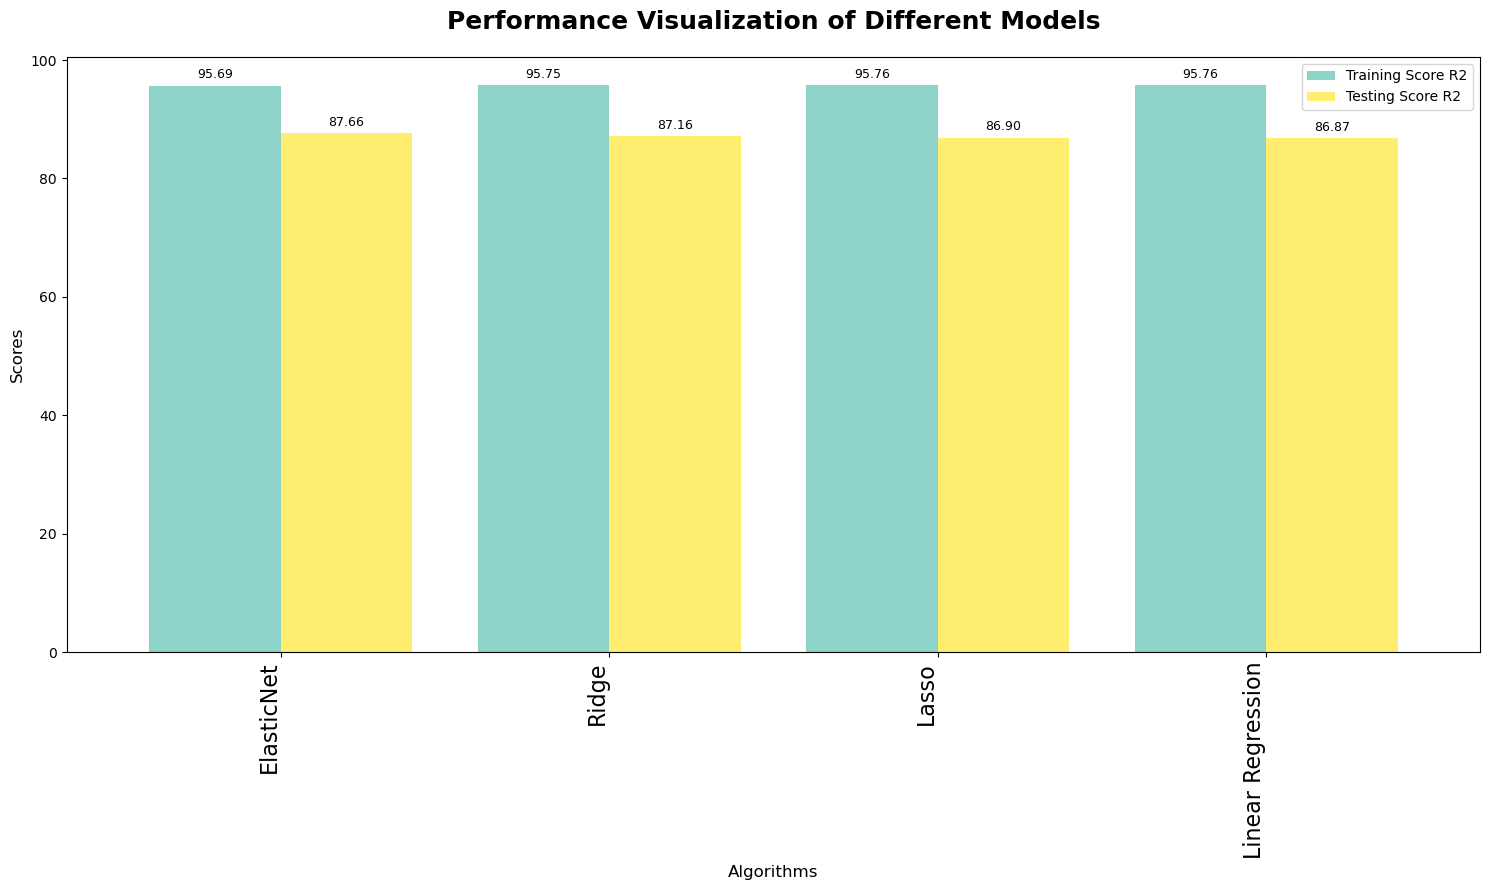

In [26]:
# Plotting bar chart for training and testing scores
ax = df_model_sort.plot(
    x="Algorithms",
    y=["Training Score R2","Testing Score R2"],
    kind="bar",
    figsize=(15, 9),
    colormap="Set3",
    width=0.8
)

# Adding title and labels
plt.title("Performance Visualization of Different Models", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=16)

# Adding data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

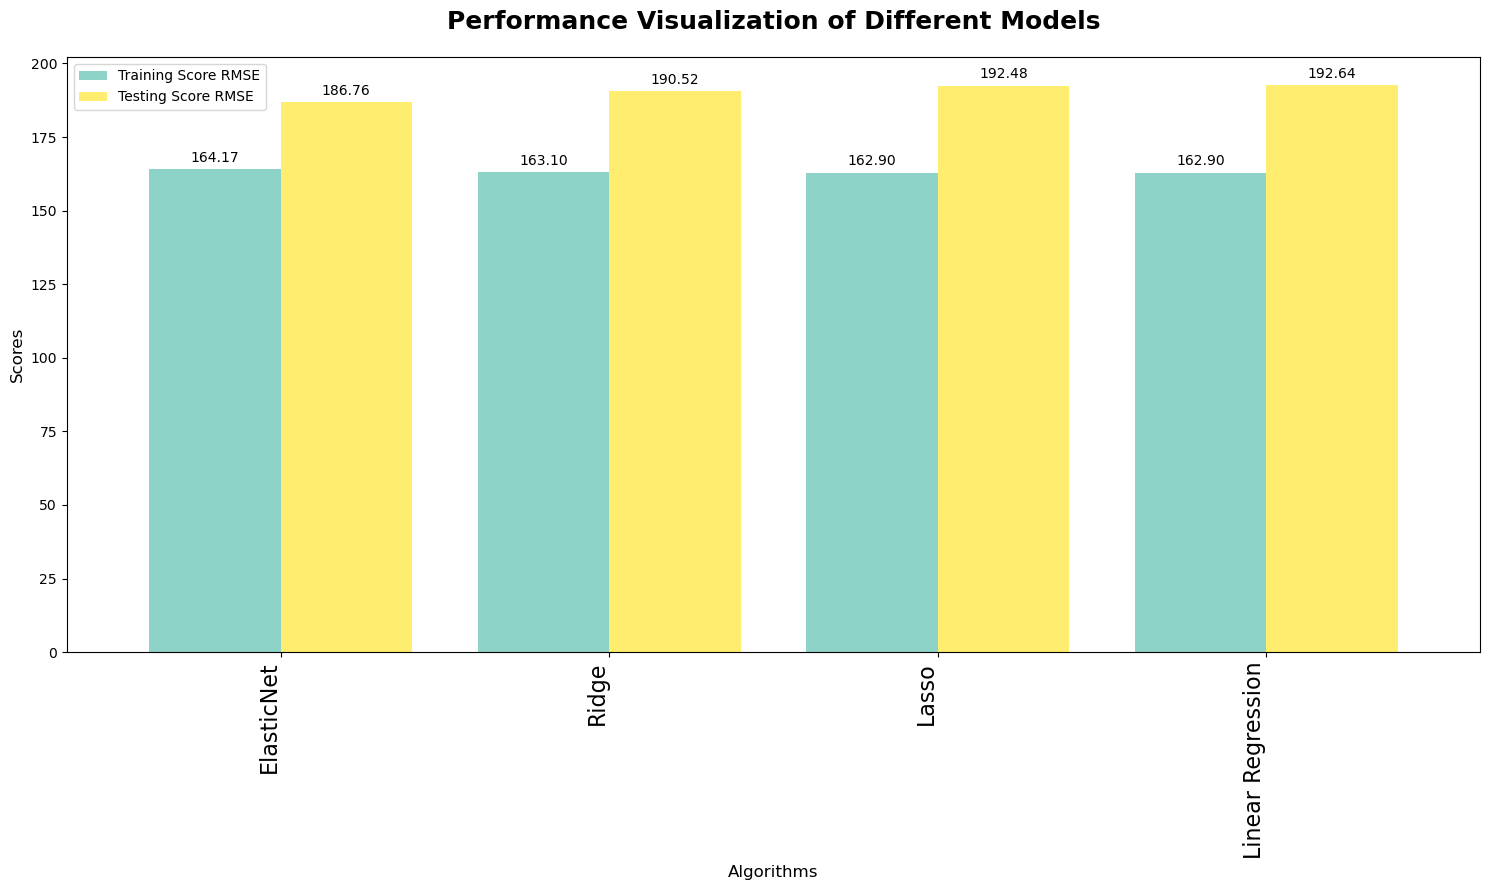

In [27]:
# Plotting bar chart for training and testing scores
ax = df_model_sort.plot(
    x="Algorithms",
    y=["Training Score RMSE","Testing Score RMSE"],
    kind="bar",
    figsize=(15, 9),
    colormap="Set3",
    width=0.8
)

# Adding title and labels
plt.title("Performance Visualization of Different Models", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=16)

# Adding data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

### Overall Interpretation: (Without EDA)

All models show very strong training performance (R² ≈ 95.7%), indicating the data has a strong linear signal.

Training RMSE values are very similar (~162–164), meaning regularization does not drastically reduce fit.

Testing R² values are also strong (≈ 86.9%–87.7%), confirming good predictive capability on unseen data.

ElasticNet performs best overall:

Highest Testing R² (87.66%)

Lowest Testing RMSE (186.76)

Highest Testing Adjusted R² (60.52%)

Smallest generalization gap

Ridge performs second best, showing that L2 regularization helps stabilize the model.

Lasso and Linear Regression perform almost identically, suggesting limited feature elimination effect.

ElasticNet improves generalization by balancing:

L1 penalty (feature shrinkage)

L2 penalty (multicollinearity control)

Testing Adjusted R² (≈ 58–60%) is significantly lower than Testing R² (~87%), indicating:

Moderate number of predictors relative to test sample size

Complexity penalty effect

Compared to your earlier results, Testing Adjusted R² has improved significantly, suggesting:

Better stability

Possibly improved train-test split or model tuning

### Final Conclusion without EDA:

The dataset is highly predictable using linear models.

Regularization slightly improves stability and reduces prediction error.

ElasticNet is the most balanced and robust model for deployment.

For final reporting, cross-validated metrics would provide a more reliable estimate than a single split.

### Modelling after EDA

In [28]:
df_with_eda = df_grouped.copy()

In [29]:
# Select only numeric columns
numeric_df = df_with_eda.select_dtypes(include='number')

# Calculate Q1, Q3 and IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers_df = (
    ((numeric_df < (Q1 - 1.5 * IQR)) | 
     (numeric_df > (Q3 + 1.5 * IQR)))
    .sum()
    .reset_index()
)

outliers_df.columns = ["Variable", "Outlier_Count"]

print("Outliers Count:\n")
print(outliers_df)

Outliers Count:

         Variable  Outlier_Count
0      product_id              0
1           price              1
2          weight             12
3     resoloution             19
4             ppi              1
5        cpu_core              0
6        cpu_freq              5
7    internal_mem              4
8             ram              0
9         rearcam              0
10      front_cam              1
11        battery              3
12      thickness              4
13  sale_quantity             12


In [30]:
# Skewness Checking
skewness_df = (df_with_eda.skew().sort_values().reset_index())
skewness_df.columns = ["Variable", "Skewness"]

print(skewness_df)

         Variable  Skewness
0        cpu_freq -0.502338
1      product_id -0.193093
2        cpu_core -0.011318
3           price  0.053899
4         rearcam  0.085922
5             ppi  0.607731
6             ram  0.801043
7     resoloution  1.210662
8       front_cam  1.250122
9       thickness  1.630595
10        battery  2.151937
11   internal_mem  2.407779
12  sale_quantity  3.821432
13         weight  4.077420


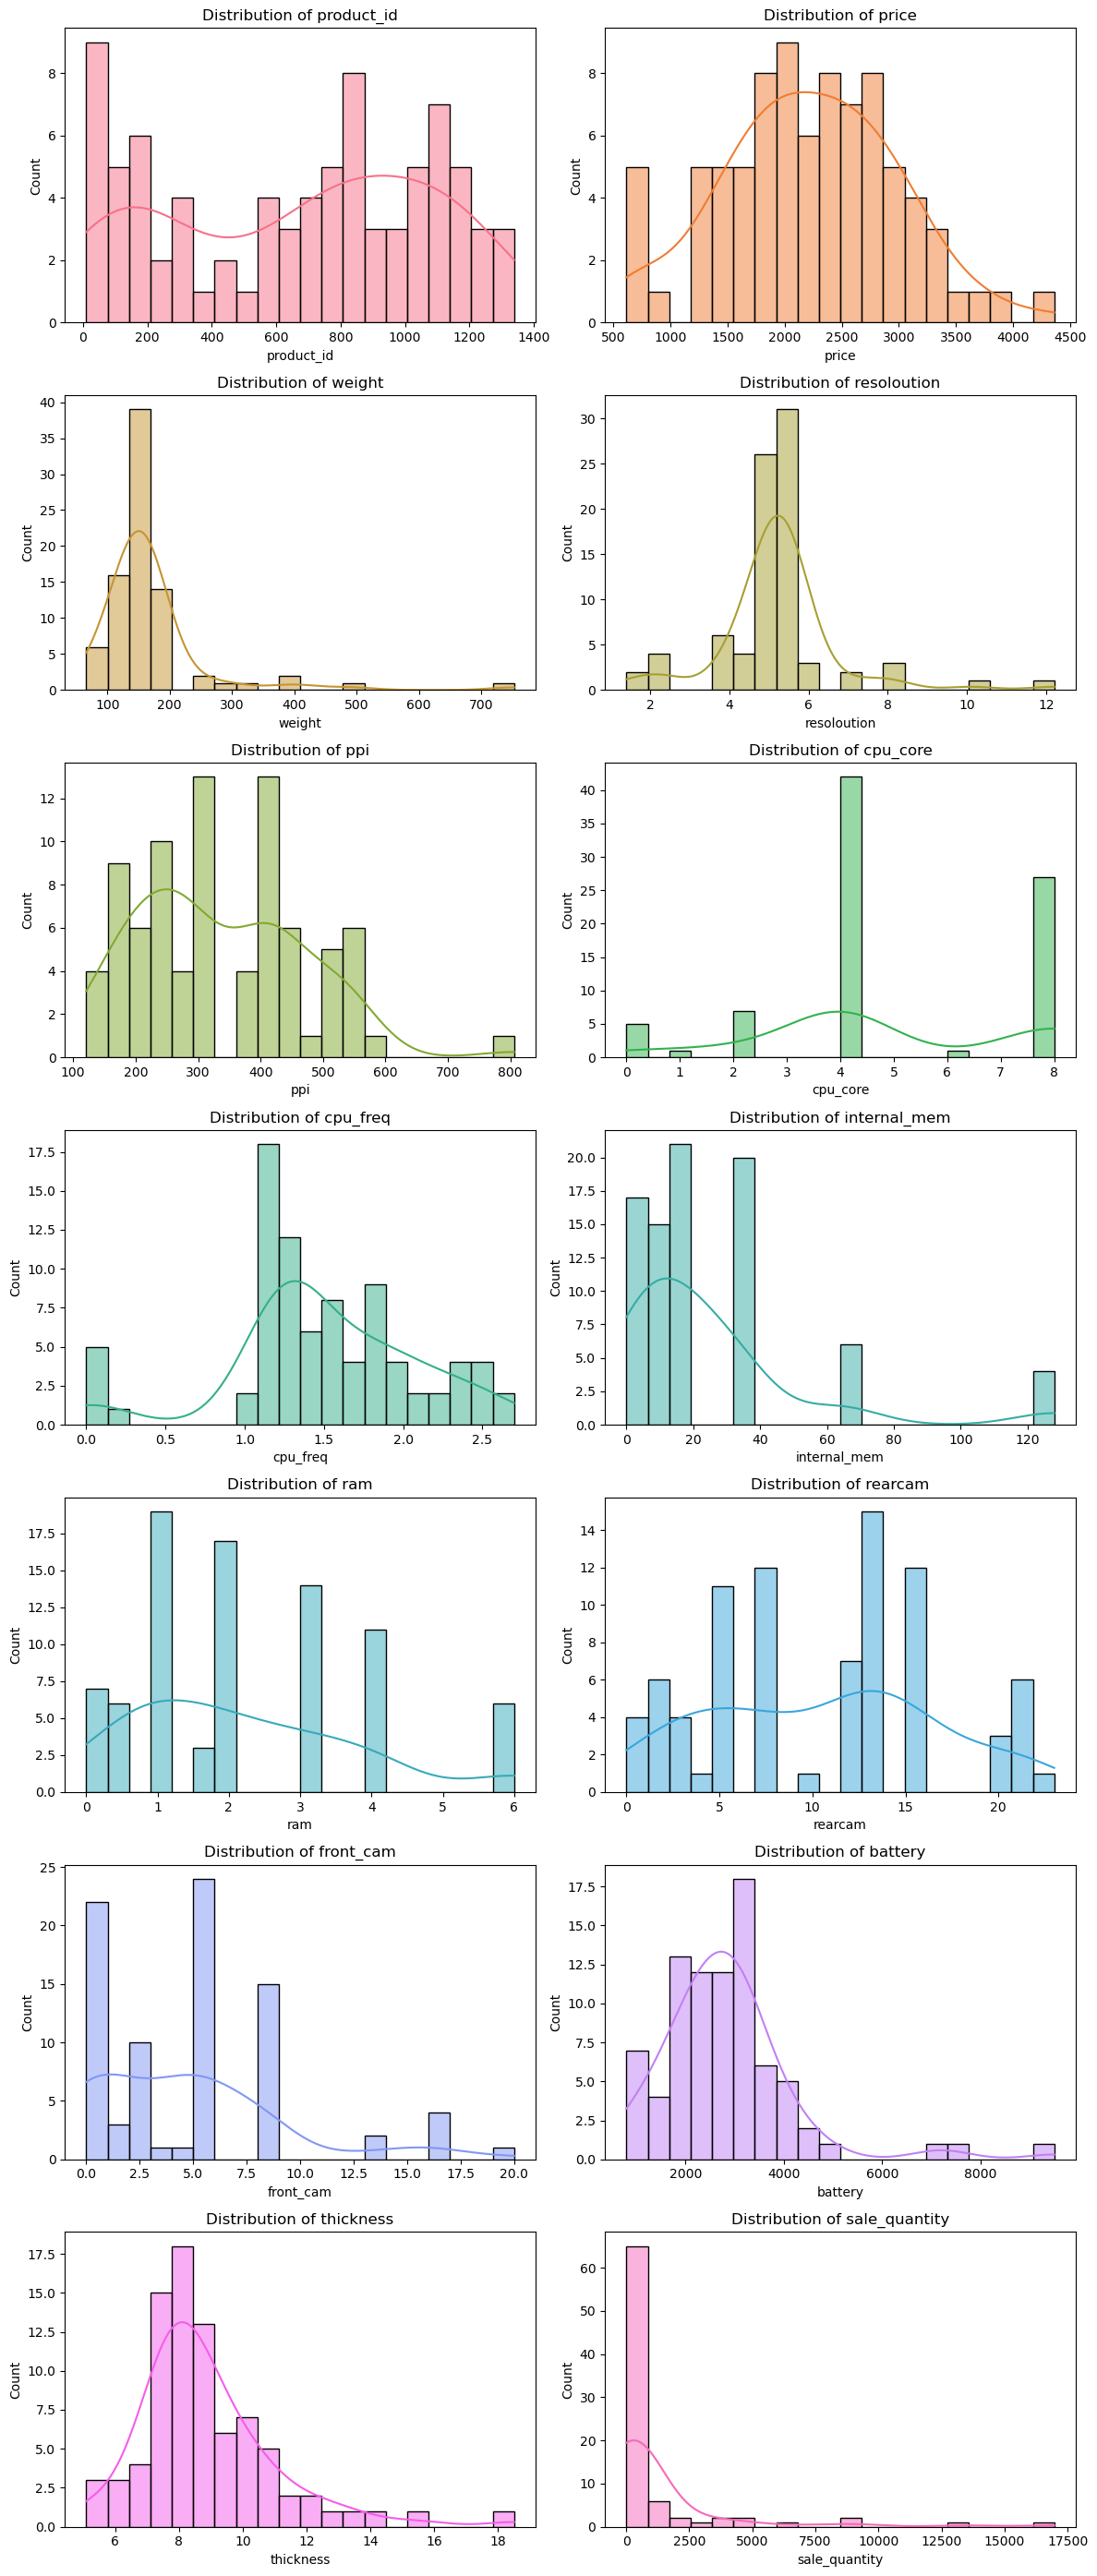

In [31]:
# Visualising the distribution for each variable 
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_data = df_with_eda.select_dtypes(include='number')

cols = numeric_data.columns
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

# Generate dynamic color palette
colors = sns.color_palette("husl", len(cols))

plt.figure(figsize=(12, 4 * n_rows))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(numeric_data[col], bins=20, kde=True, color=color)
    plt.title(f"Distribution of {col}")
    
plt.tight_layout()
plt.show()

### Transformation using the method 'Yeo-Johnson'¶

In [32]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# Select numeric columns only
req_df = df_with_eda.drop(columns=['product_id', 'sale_quantity'])
                 
numeric_cols = req_df.select_dtypes(include='number').columns

# Initialize transformer
pt = PowerTransformer(method='yeo-johnson')

# Apply transformation
req_df[numeric_cols] = pt.fit_transform(req_df[numeric_cols])

print("Yeo-Johnson Transformation Applied Successfully")
req_df

Yeo-Johnson Transformation Applied Successfully


,price,weight,resoloution,ppi,cpu_core,cpu_freq,internal_mem,ram,rearcam,front_cam,battery,thickness
0,-0.339740,-0.776249,-0.091204,-1.188532,-0.338493,-0.412047,-0.503441,-0.693890,-0.315488,-0.377905,-0.575919,-1.418135
1,0.089196,-0.835484,-0.091204,-0.173761,1.266658,-0.069560,0.038005,0.075481,0.468218,0.398844,-0.274399,-0.417847
2,0.993081,-0.024887,0.247667,1.385086,1.266658,0.107203,0.672490,0.655953,0.900433,0.909886,0.319369,-0.952557
3,-0.378165,0.497345,0.575814,-1.222393,-0.338493,-0.412047,-0.503441,-0.693890,0.468218,0.909886,-0.021028,-0.297040
4,-0.384795,-1.023364,-0.300200,-0.030327,-0.338493,-0.577623,-0.503441,-0.277337,0.468218,0.398844,-0.575919,-0.543476
...,...,...,...,...,...,...,...,...,...,...,...,...
78,0.657831,0.111183,0.247667,0.603373,1.266658,-0.327827,0.038005,0.075481,0.468218,0.398844,-0.274399,-2.691346
79,1.859682,0.323173,0.011655,0.775570,1.266658,1.748567,1.403793,1.873728,0.318641,0.909886,0.574115,-0.608196
80,1.294173,0.356173,0.247667,1.385086,-0.338493,0.801501,2.239379,1.873728,1.445416,0.909886,0.608689,-0.356859
81,-0.272277,0.719675,0.380148,-0.480504,-0.338493,-0.577623,0.038005,0.075481,-0.315488,-0.781394,0.608689,0.781666


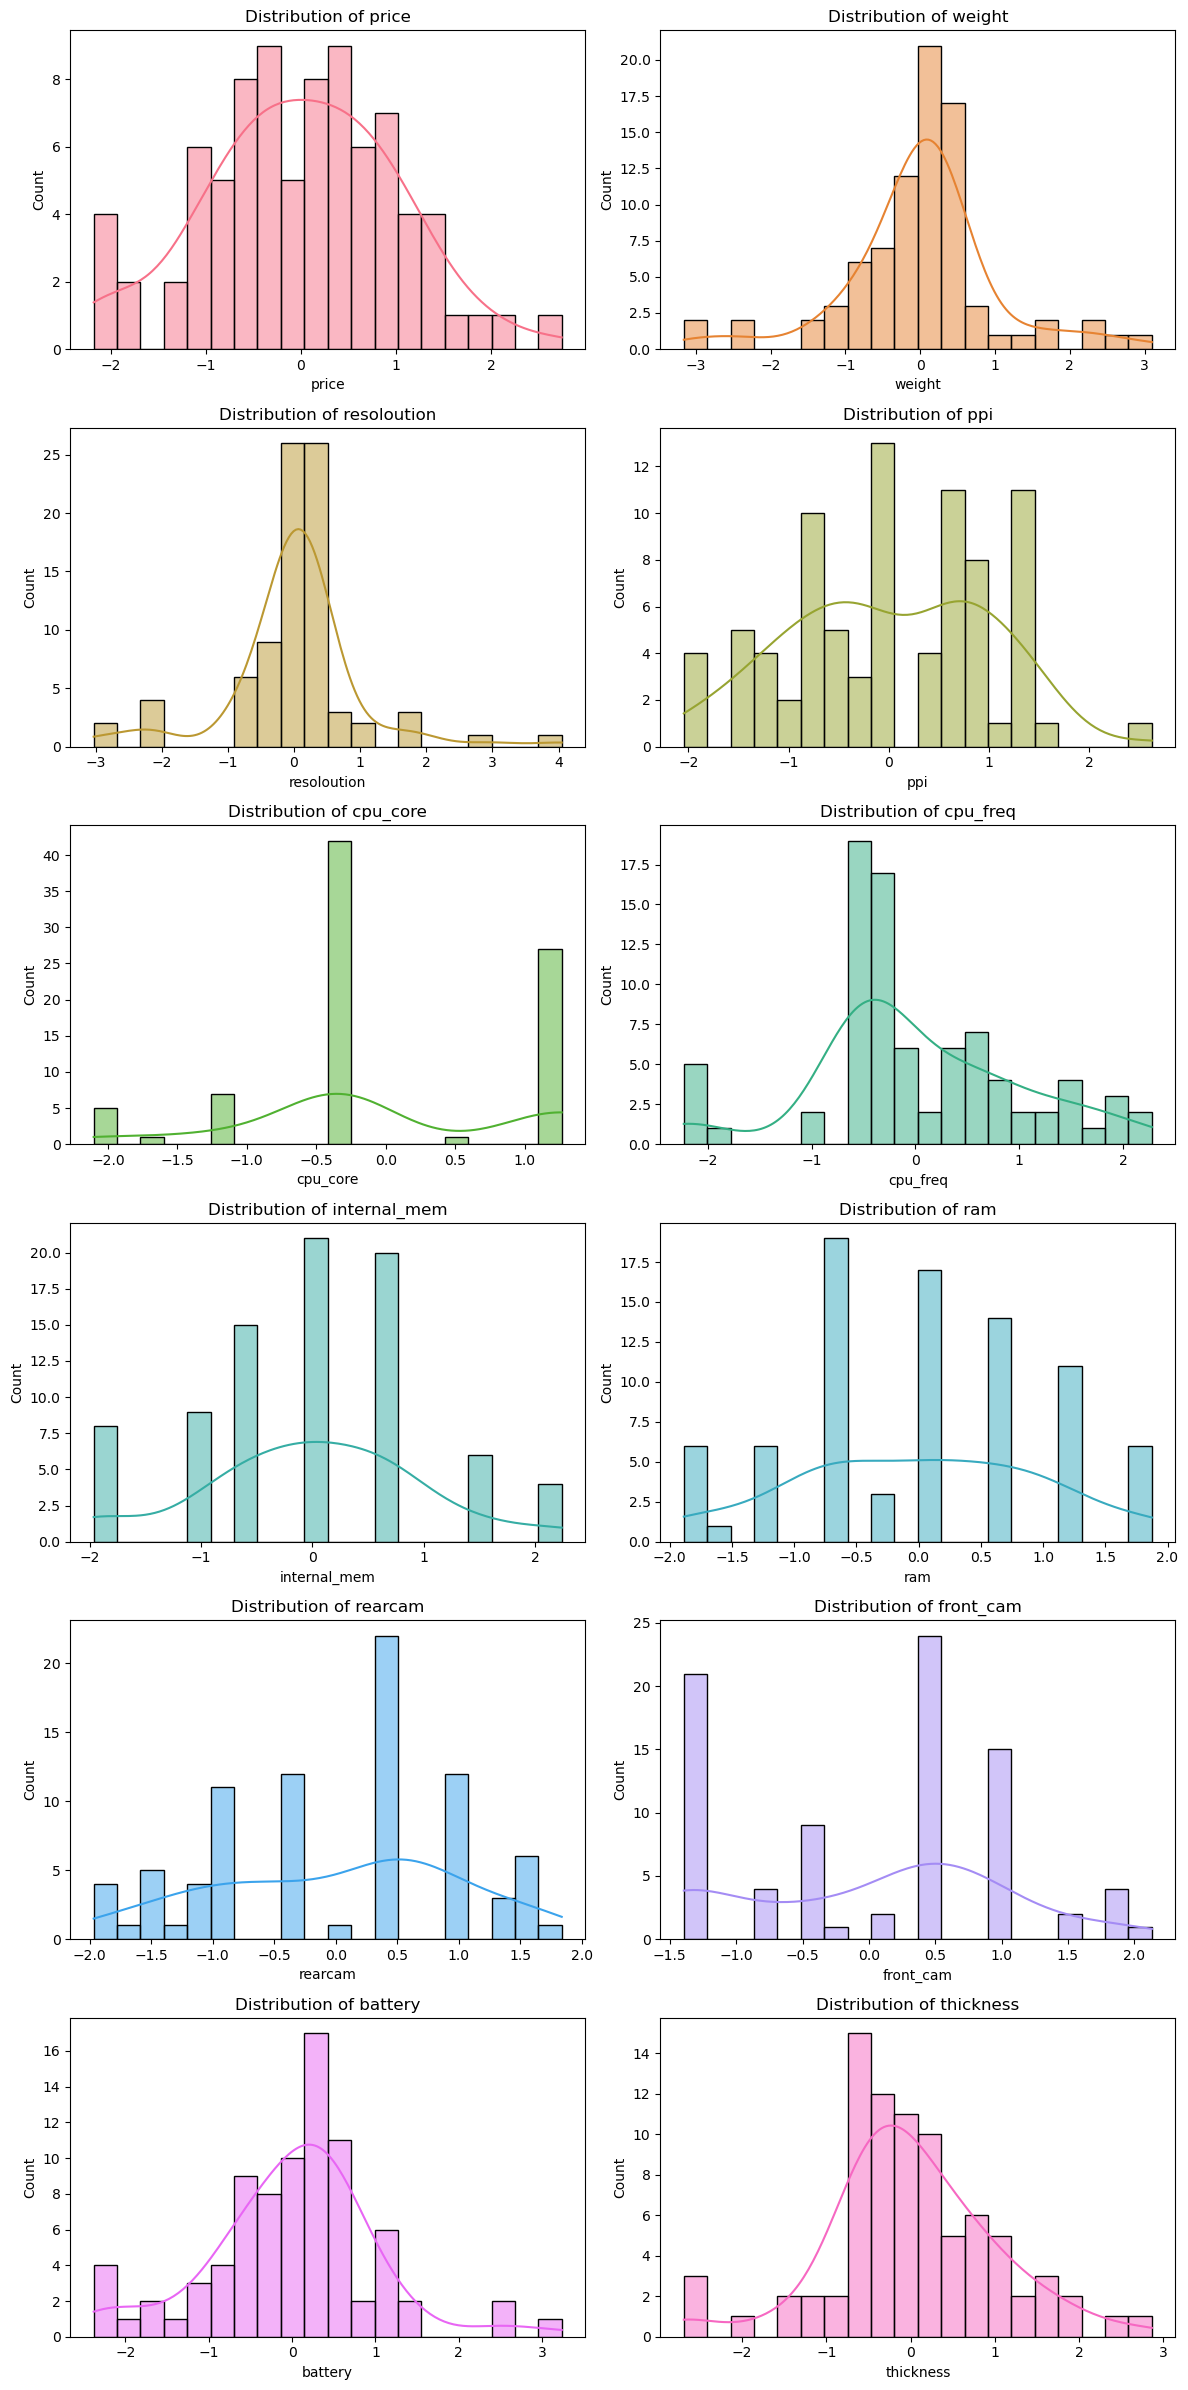

In [34]:
req_df_with_transformation = req_df.copy()
# Visualising the distribution for each variable 
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = req_df_with_transformation.columns
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

# Generate dynamic color palette
colors = sns.color_palette("husl", len(cols))

plt.figure(figsize=(12, 4 * n_rows))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(req_df_with_transformation[col], bins=20, kde=True, color=color)
    plt.title(f"Distribution of {col}")
    
plt.tight_layout()
plt.show()

### Variance Inflation Factor

In [35]:
vif_data = req_df_with_transformation.copy()



In [36]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) 
                  for i in range(X.shape[1])]
    return vif

def remove_high_vif(X, threshold=10):
    X = X.copy()
    iteration_log = []
    iteration = 1

    while True:
        vif = calculate_vif(X)
        max_vif = vif["VIF"].max()

        if max_vif > threshold:
            feature_to_drop = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]

            # Store iteration details
            iteration_log.append({
                "Iteration": iteration,
                "Removed_Feature": feature_to_drop,
                "VIF_at_Removal": max_vif
            })

            print(f"Iteration {iteration}: Dropping '{feature_to_drop}' (VIF = {max_vif:.2f})")

            X = X.drop(columns=[feature_to_drop])
            iteration += 1
        else:
            break

    log_df = pd.DataFrame(iteration_log)

    return X, calculate_vif(X), log_df



##### VIF of the independent columns should be less than 10 to remove multicollinearity

In [37]:

# Usage
X_reduced, final_vif, removal_log = remove_high_vif(vif_data, threshold=10)

print("\nRemoved Variables Log:")
print(removal_log)

print("\nFinal Features:")
print(X_reduced.columns)

print("\nFinal VIF Table:")
print(final_vif)

Iteration 1: Dropping 'resoloution' (VIF = 18.18)
Iteration 2: Dropping 'price' (VIF = 14.61)
Iteration 3: Dropping 'ram' (VIF = 11.90)

Removed Variables Log:
   Iteration Removed_Feature  VIF_at_Removal
0          1     resoloution       18.179660
1          2           price       14.610509
2          3             ram       11.896693

Final Features:
Index(['weight', 'ppi', 'cpu_core', 'cpu_freq', 'internal_mem', 'rearcam',
       'front_cam', 'battery', 'thickness'],
      dtype='object')

Final VIF Table:
        Feature       VIF
0        weight  5.049716
1           ppi  5.919398
2      cpu_core  2.938438
3      cpu_freq  3.030552
4  internal_mem  5.457930
5       rearcam  4.045254
6     front_cam  3.596519
7       battery  7.686060
8     thickness  2.214946


In [38]:
X_reduced

,weight,ppi,cpu_core,cpu_freq,internal_mem,rearcam,front_cam,battery,thickness
0,-0.776249,-1.188532,-0.338493,-0.412047,-0.503441,-0.315488,-0.377905,-0.575919,-1.418135
1,-0.835484,-0.173761,1.266658,-0.069560,0.038005,0.468218,0.398844,-0.274399,-0.417847
2,-0.024887,1.385086,1.266658,0.107203,0.672490,0.900433,0.909886,0.319369,-0.952557
3,0.497345,-1.222393,-0.338493,-0.412047,-0.503441,0.468218,0.909886,-0.021028,-0.297040
4,-1.023364,-0.030327,-0.338493,-0.577623,-0.503441,0.468218,0.398844,-0.575919,-0.543476
...,...,...,...,...,...,...,...,...,...
78,0.111183,0.603373,1.266658,-0.327827,0.038005,0.468218,0.398844,-0.274399,-2.691346
79,0.323173,0.775570,1.266658,1.748567,1.403793,0.318641,0.909886,0.574115,-0.608196
80,0.356173,1.385086,-0.338493,0.801501,2.239379,1.445416,0.909886,0.608689,-0.356859
81,0.719675,-0.480504,-0.338493,-0.577623,0.038005,-0.315488,-0.781394,0.608689,0.781666


In [ ]:
### Storing the performence metrics score

In [39]:
training_scores_r2 = []
training_scores_adj_r2 = []
training_scores_rmse = []

testing_scores_r2 = []
testing_scores_adj_r2 = []
testing_scores_rmse = []

In [40]:
### Storing the performence metrics score

In [41]:
def evaluate_model_performance(model, x_train, y_train, x_test, y_test):
    """
    Evaluates R², Adjusted R², and RMSE of a given model on training and testing data.
    
    Parameters:
    - model: The machine learning model to evaluate
    - x_train: Training feature set
    - y_train: Training target values
    - x_test: Testing feature set
    - y_test: Testing target values
    - training_scores: List to store training R² scores
    - testing_scores: List to store testing R² scores
    """
    # Fit the model
    model.fit(x_train, y_train)
    
    # Predictions for training and testing data
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Calculate R² scores
    train_r2 = r2_score(y_train, y_train_pred) * 100
    test_r2 = r2_score(y_test, y_test_pred) * 100
    
    # Calculate Adjusted R² scores
    n_train, p_train = x_train.shape
    n_test, p_test = x_test.shape
    train_adj_r2 = 100 * (1 - (1 - train_r2 / 100) * (n_train - 1) / (n_train - p_train - 1))
    test_adj_r2 = 100 * (1 - (1 - test_r2 / 100) * (n_test - 1) / (n_test - p_test - 1))
    
    # Calculate RMSE scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Append scores to respective lists
    training_scores_r2.append(train_r2)
    training_scores_adj_r2.append(train_adj_r2)
    training_scores_rmse.append(train_rmse)
    testing_scores_r2.append(test_r2)
    testing_scores_adj_r2.append(test_adj_r2) 
    testing_scores_rmse.append(test_rmse) 
    
    # Display scores
    print(f"{model.__class__.__name__} Performance Metrics:")
    print(f"Training Data: R² = {train_r2:.2f}%, Adjusted R² = {train_adj_r2:.2f}%, RMSE = {train_rmse:.4f}")
    print(f"Testing Data : R² = {test_r2:.2f}%, Adjusted R² = {test_adj_r2:.2f}%, RMSE = {test_rmse:.4f}\n")

In [42]:
### Split the data into dependent and independent variable

In [43]:
x = X_reduced
y = req_df_with_transformation['price']

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [45]:
print("x_train - >  ",x_train.shape)
print("y_train - >  ",y_train.shape)
print("x_test  - >  ",x_test.shape)
print("y_test  - >  ",y_test.shape)

x_train - >   (66, 9)
y_train - >   (66,)
x_test  - >   (17, 9)
y_test  - >   (17,)


In [46]:
evaluate_model_performance(
    model=LinearRegression(),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

LinearRegression Performance Metrics:
Training Data: R² = 92.96%, Adjusted R² = 91.83%, RMSE = 0.2762
Testing Data : R² = 85.60%, Adjusted R² = 67.09%, RMSE = 0.2688



In [47]:
# Create the Ridge Regression model
ridge_regressor = Ridge(
    alpha=1.0,                  # Regularization strength
    fit_intercept=True,         # Whether to calculate the intercept (bias) term
    copy_X=True,                # If True, it makes a copy of the input matrix X
    max_iter=None,              # Maximum number of iterations for the solver
    tol=0.001,                  # Tolerance for stopping criteria
    solver='auto',              # Solver to use ('auto', 'lsqr', 'saga', etc.)
    random_state=None,          # Random state for reproducibility
    positive=False              # If True, coefficients are constrained to be positive
)

In [48]:
evaluate_model_performance(
    model=ridge_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Ridge Performance Metrics:
Training Data: R² = 92.94%, Adjusted R² = 91.80%, RMSE = 0.2767
Testing Data : R² = 86.23%, Adjusted R² = 68.53%, RMSE = 0.2629



In [49]:
# Create the Lasso Regression model
lasso_regressor = Lasso(
    alpha=1.0,                  # Regularization strength
    fit_intercept=True,         # Whether to calculate the intercept (bias) term
    copy_X=True,                # If True, it makes a copy of the input matrix X
    max_iter=1000,              # Maximum number of iterations for the solver
    tol=0.0001,                 # Tolerance for stopping criteria
    random_state=None,          # Random state for reproducibility
    positive=False              # If True, coefficients are constrained to be positive
)

In [50]:
evaluate_model_performance(
    model=lasso_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

Lasso Performance Metrics:
Training Data: R² = 0.00%, Adjusted R² = -16.07%, RMSE = 1.0412
Testing Data : R² = -42.93%, Adjusted R² = -226.69%, RMSE = 0.8470



In [51]:
# Create the ElasticNet Regression model
elasticnet_regressor = ElasticNet(
    alpha=1.0,                  # Regularization strength
    l1_ratio=0.5,               # The balance between Lasso (L1) and Ridge (L2) regularization (0 is Ridge, 1 is Lasso)
    fit_intercept=True,         # Whether to calculate the intercept (bias) term
    copy_X=True,                # If True, it makes a copy of the input matrix X
    max_iter=1000,              # Maximum number of iterations for the solver
    tol=0.0001,                 # Tolerance for stopping criteria
    random_state=None,          # Random state for reproducibility
    positive=False              # If True, coefficients are constrained to be positive
)

In [52]:
evaluate_model_performance(
    model=elasticnet_regressor,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)

ElasticNet Performance Metrics:
Training Data: R² = 54.54%, Adjusted R² = 47.23%, RMSE = 0.7020
Testing Data : R² = 40.77%, Adjusted R² = -35.39%, RMSE = 0.5453



In [54]:
models = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "ElasticNet",
    ]

In [56]:
df_model = pd.DataFrame(
        {"Algorithms_With_EDA":models,
         "Training Score R2":training_scores_r2,
         "Training Score Adjusted R2":training_scores_adj_r2,
         "Training Score RMSE":training_scores_rmse,
         "Testing Score R2":testing_scores_r2,
         "Testing Score Adjusted R2":testing_scores_adj_r2,
         "Testing Score RMSE":testing_scores_rmse,
        })
				   
df_model_sort = df_model.sort_values(by="Testing Score R2", ascending=False)
df_model_sort

,Algorithms_With_EDA,Training Score R2,Training Score Adjusted R2,Training Score RMSE,Testing Score R2,Testing Score Adjusted R2,Testing Score RMSE
1,Ridge,92.939517,91.804797,0.276668,86.233827,68.534463,0.262880
0,Linear Regression,92.964487,91.833780,0.276179,85.602502,67.091433,0.268841
3,ElasticNet,54.540299,47.234276,0.702030,40.768358,-35.386610,0.545291
2,Lasso,0.000000,-16.071429,1.041219,-42.925703,-226.687322,0.847045


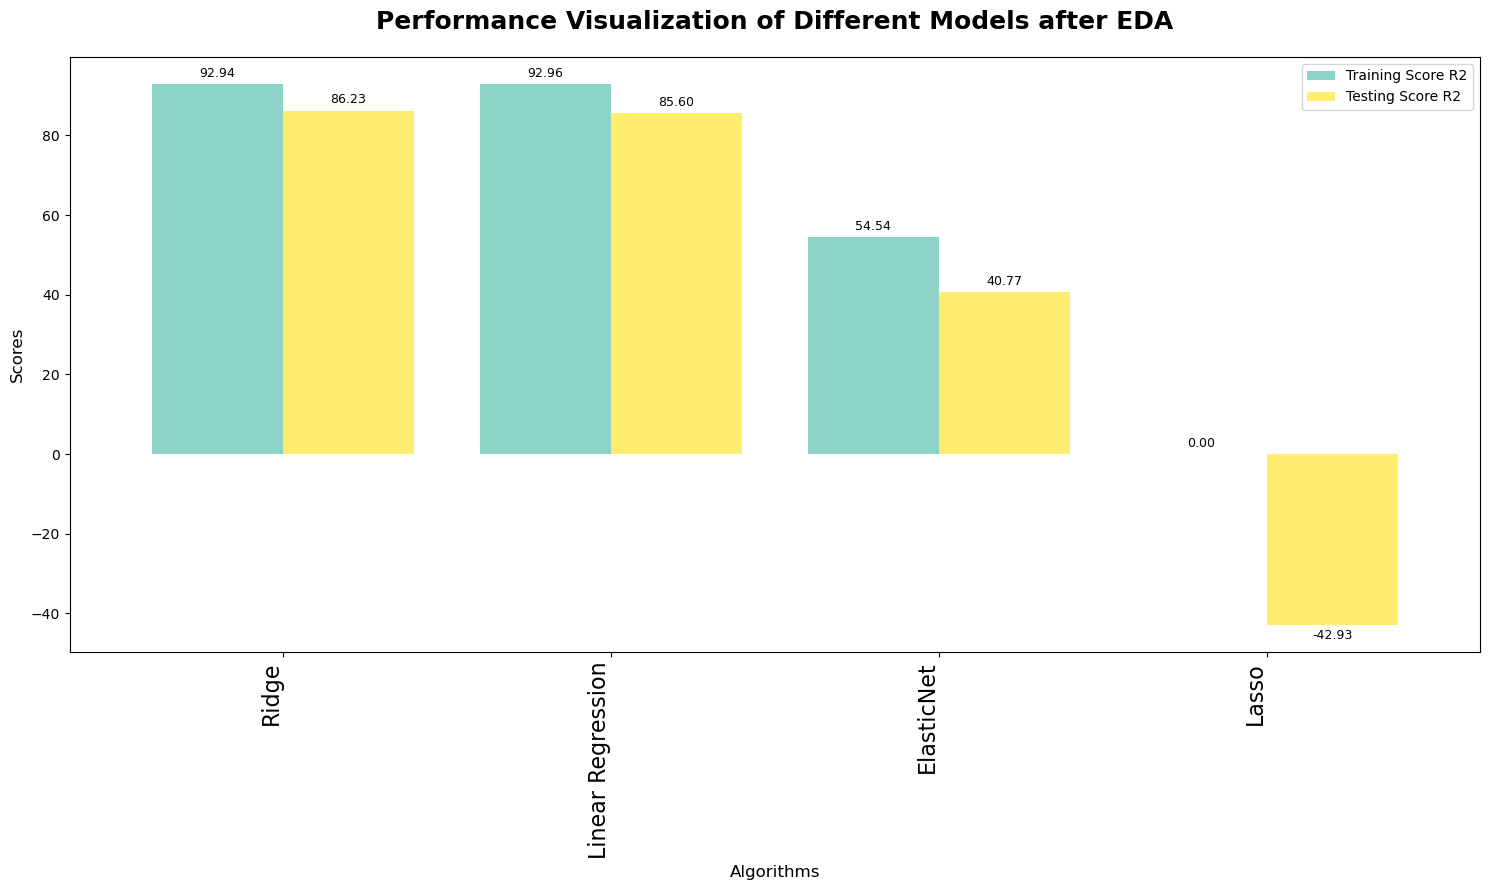

In [58]:
# Plotting bar chart for training and testing scores
ax = df_model_sort.plot(
    x="Algorithms_With_EDA",
    y=["Training Score R2","Testing Score R2"],
    kind="bar",
    figsize=(15, 9),
    colormap="Set3",
    width=0.8
)

# Adding title and labels
plt.title("Performance Visualization of Different Models after EDA", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=16)

# Adding data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

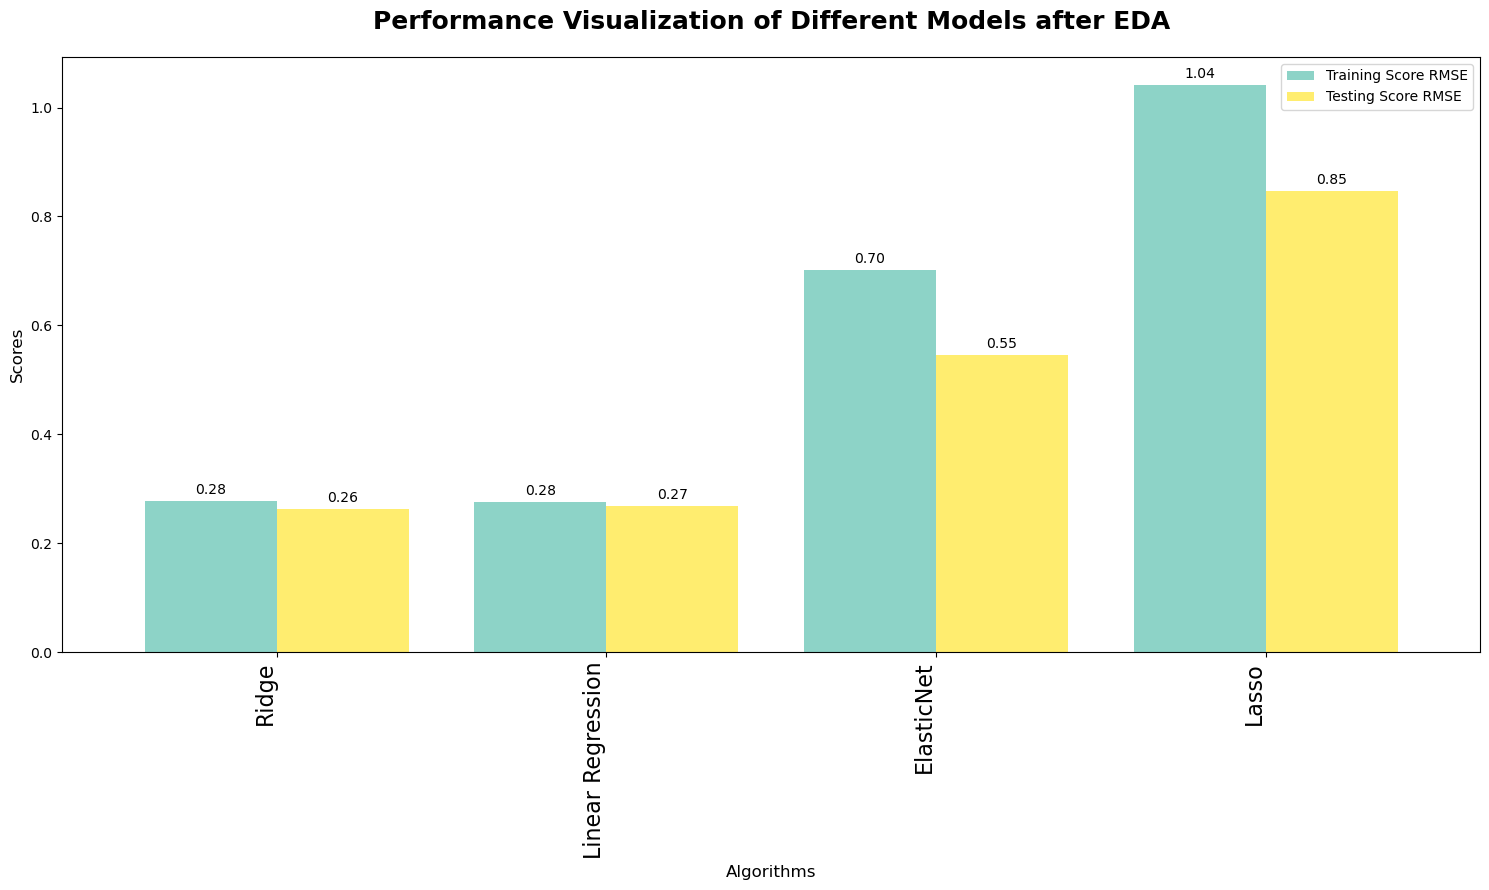

In [60]:
# Plotting bar chart for training and testing scores
ax = df_model_sort.plot(
    x="Algorithms_With_EDA",
    y=["Training Score RMSE","Testing Score RMSE"],
    kind="bar",
    figsize=(15, 9),
    colormap="Set3",
    width=0.8
)

# Adding title and labels
plt.title("Performance Visualization of Different Models after EDA", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=16)

# Adding data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

### Overall Insights with EDA

Ridge Regression performed the best with the highest Testing R² (86.23%) and lowest RMSE (0.2629). It generalizes well and controls variance effectively.

Linear Regression performed almost as well as Ridge (Testing R² = 85.60%). Slightly higher RMSE but still strong and stable.

ElasticNet shows underfitting. Training and Testing R² are low (54.54% and 40.77%). Regularization is likely too strong.

Lasso performed very poorly. Training R² is 0% and Testing R² is negative (-42.93%), indicating severe underfitting and over-penalization.

Ridge regularization helped improve stability compared to simple Linear Regression.

Strong regularization (Lasso and ElasticNet) reduced model performance significantly.


#### Conclusion:
Ridge Regression is the best model among all, as it provides the best balance between bias and variance with strong generalization performance.


### Final Model Conclusion:

### Overall Insights (Before EDA vs After EDA)


- Before EDA, all models performed similarly with high Testing R² (around 86–87%).

- After EDA, Ridge and Linear Regression remained strong, but ElasticNet and Lasso performance dropped significantly.

- Ridge became the best and most stable model after EDA (Testing R² ≈ 86.23%).

- Linear Regression remained consistent with only a slight drop in performance.

- ElasticNet showed strong performance before EDA but underperformed heavily after EDA, indicating over-regularization.

- Lasso completely failed after EDA (negative Testing R²), showing severe underfitting due to strong regularization.

- `EDA reduced overfitting `by lowering Training R² and stabilizing generalization for Ridge and Linear models.

- RMSE values cannot be directly compared because the scale changed after transformation.

### 🏆 Final Conclusion 

### `After EDA, Ridge Regression is the most reliable and stable model.`